In [1]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 74.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 50.2 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 90.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 98.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 76.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 40.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 46.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.1 MB/s  0:00:00
  Attempting uninstall: jupyterlab━━╺━━━━━━━━━━━ 12/17 [seaborn]ts]
    Found existing installation: jupyterlab 4.5.00m━━━━━━━━━━━ 12/17 [seaborn]
    Uninstalling jupyterlab-4.5.0:0m╺━━━━━━━━━━━ 12/17 [seaborn]
      Successfully

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Data/processed_data.csv")


In [3]:
df

,time,aeration,rpm,feed_rate,Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,cum_feed,growth_rate,penicillin_rate,oxygen_efficiency,mixing_intensity,biomass_smooth,penicillin_smooth,biomass_lag1,penicillin_lag1,our_lag1
0,0.2,30,100,8,0.0000,30.1180,9.8335,0.0001,0,0.6,...,1.6,0.000,0.000000,0.016017,3000,0.614237,0.000799,0.000,0.000000e+00,0.000000
1,0.4,30,100,8,0.0000,51.2210,18.1550,0.0001,0,0.6,...,3.2,0.000,0.005000,0.001938,3000,0.614237,0.000799,0.000,1.017800e-25,0.480510
2,0.6,30,100,8,0.0000,54.3020,9.5982,0.0001,0,0.6,...,4.8,0.000,-0.000003,0.000000,3000,0.614237,0.000799,0.000,1.000000e-03,0.058147
3,0.8,30,100,8,0.0000,37.8160,4.3395,0.0001,0,0.6,...,6.4,0.000,-0.000003,0.000000,3000,0.614237,0.000799,0.000,9.993400e-04,-0.041505
4,1.0,30,100,8,0.5181,18.9080,1.1045,0.0001,0,0.6,...,8.0,0.000,-0.000003,0.000000,3000,0.614237,0.000799,0.000,9.987400e-04,-0.056737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11580,229.2,65,100,80,0.0000,17.7970,22.8130,93.4870,250,0.9,...,177446.0,-0.085,-0.105000,0.011131,6500,20.140000,15.537600,20.123,1.551600e+01,0.732810
11581,229.4,65,100,80,0.0000,17.9450,71.0210,9.3487,250,0.9,...,177462.0,-0.085,-0.105000,0.011169,6500,20.123000,15.516400,20.106,1.549500e+01,0.723540
11582,229.6,65,100,80,0.0000,15.4730,21.3060,156.6800,250,0.9,...,177478.0,-0.085,-0.110000,0.011310,6500,20.106000,15.495000,20.089,1.547400e+01,0.725980
11583,229.8,65,100,80,0.0000,12.1100,125.6700,15.6680,250,0.9,...,177494.0,-0.085,-0.105000,0.011424,6500,20.089000,15.473600,20.072,1.545200e+01,0.735130


In [4]:
df["penicillin_next"] = df.groupby("batch_id")["penicillin"].shift(-1)
df["biomass_next"] = df.groupby("batch_id")["biomass"].shift(-1)
df = df.dropna(subset=["penicillin_next", "biomass_next"])
#The model predicts: state(t+1)


In [6]:
df.columns

Index(['time', 'aeration', 'rpm', 'feed_rate', 'Acid flow rate(Fa:L/h)',
       'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)',
       'Heating water flow rate(Fh:L/h)',
       'Water for injection/dilution(Fw:L/h)',
       'Air head pressure(pressure:bar)', 'Dumped broth flow(Fremoved:L/h)',
       'Substrate concentration(S:g/L)', 'do', 'penicillin',
       'Vessel Volume(V:L)', 'Vessel Weight(Wt:Kg)', 'ph', 'temp',
       'Generated heat(Q:kJ)',
       'carbon dioxide percent in off-gas(CO2outgas:%)',
       'PAA flow(Fpaa:PAA flow (L/h))',
       'PAA concentration offline(PAA_offline:PAA (g L^{-1}))',
       'Oil flow(Foil:L/hr)',
       'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))', 'our',
       'Oxygen in percent in off-gas(O2:O2  (%))',
       'Offline Penicillin concentration(P_offline:P(g L^{-1}))', 'biomass',
       'cer', 'Ammonia shots(NH3_shots:kgs)',
       'Viscosity(Viscosity_offline:centPoise)',
       'Fault reference(Fault_ref:Fault

In [9]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 49.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 86.2 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
#DONT USE LAG FEATURES, CAUSES OVERFITTING
# create delta targets
df["penicillin_delta"] = df["penicillin_next"] - df["penicillin_lag1"]
df["biomass_delta"] = df["biomass_next"] - df["biomass_lag1"]

In [21]:
features = [
    "time",
    "rpm",
    "aeration",
    "feed_rate",
    "cum_feed",
    "our",
    "cer",
    "do",
    "temp",
    "ph",
    "mixing_intensity",
    "oxygen_efficiency",
    "growth_rate",
    "penicillin_rate",
    "biomass_lag1",
    "our_lag1"
]

In [22]:
batches = df["batch_id"].unique()

train_batches = batches[:int(0.8 * len(batches))]
test_batches = batches[int(0.8 * len(batches)):]

train = df[df["batch_id"].isin(train_batches)]
test = df[df["batch_id"].isin(test_batches)]

In [23]:
X_train = train[features]
X_test = test[features]

y_train_p = train["penicillin_delta"]
y_test_p = test["penicillin_delta"]

y_train_x = train["biomass_delta"]
y_test_x = test["biomass_delta"]

In [24]:
from sklearn.ensemble import RandomForestRegressor

model_p = RandomForestRegressor(random_state=42)
model_x = RandomForestRegressor(random_state=42)

model_p.fit(X_train, y_train_p)
model_x.fit(X_train, y_train_x)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

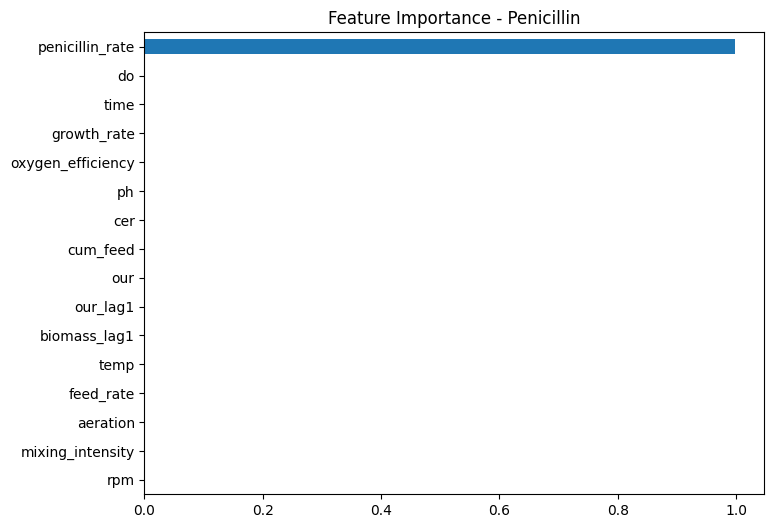

In [27]:
delta_pred_p = model_p.predict(X_test)
delta_pred_x = model_x.predict(X_test)
importance = pd.Series(model_p.feature_importances_, index=features)
importance = importance.sort_values()

plt.figure(figsize=(8,6))
importance.plot(kind="barh")
plt.title("Feature Importance - Penicillin")
plt.show()